In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("com.csv")

# See first rows
print(df.head())

# Check structure
print(df.info())

                           order_id                       customer_id  \
0  23fbbf4e70a72006ecb1a4bdd72a5d0f  373373ec4d694242d601fe8a69be1c92   
1  18f4178d9b3c33fa79c1a0d5eb214023  1f68e24da06f36cb8a5243e23c390bcf   
2  1c2bab4c18a97c3bba457866ee72bdbd  9f582ffae8aecd135ae3d11fcd508c26   
3  f192cff10ef337b0ec9028f2cb9bf874  1c3f1e66dc3859cce89cb9c12e3c1122   
4  351688388d33d4a58285b9d6630bcc82  32755045a3b602adc3876bbfa3f8d7c8   

    customer_city customer_state  order_date order_month  \
0           barra             BA  2017-10-05     2017-10   
1  belo horizonte             MG  2018-05-07     2018-05   
2    juiz de fora             MG  2017-09-20     2017-09   
3        salvador             BA  2017-07-21     2017-07   
4  rio de janeiro             RJ  2018-04-21     2018-04   

                         product_id product_category_name   price  \
0  b551128533846968d8752358d1f7f365        sports_leisure   43.90   
1  680874c570dad71c0a2844cfbf417054       furniture_decor   39

In [2]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6538 entries, 0 to 6537
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               6538 non-null   object        
 1   customer_id            6537 non-null   object        
 2   customer_city          6537 non-null   object        
 3   customer_state         6537 non-null   object        
 4   order_date             6537 non-null   datetime64[ns]
 5   order_month            6537 non-null   object        
 6   product_id             6537 non-null   object        
 7   product_category_name  6537 non-null   object        
 8   price                  6537 non-null   float64       
 9   payment_value          6537 non-null   float64       
 10  review_score           6537 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 562.0+ KB


In [3]:
# First purchase date per user
first_purchase = df.groupby('customer_id')['order_date'].min().reset_index()

# Rename column
first_purchase.columns = ['customer_id', 'first_purchase_date']

# View
first_purchase.head()

,customer_id,first_purchase_date
0,0009a69b72033b2d0ec8c69fc70ef768,2017-04-28
1,000e943451fc2788ca6ac98a682f2f49,2017-04-20
2,001450ebb4a77efb3d68be5f7887cb1e,2018-02-26
3,00155f0530cc7b2bf73cc3f81cb01c52,2017-05-14
4,0018f7fde63ca77254dbc47f4ea358b2,2017-09-26


In [4]:
# Count orders per user
user_orders = df.groupby('customer_id')['order_id'].count().reset_index()

# Rename column
user_orders.columns = ['customer_id', 'order_count']

# View result
user_orders.head()

,customer_id,order_count
0,0009a69b72033b2d0ec8c69fc70ef768,1
1,000e943451fc2788ca6ac98a682f2f49,1
2,001450ebb4a77efb3d68be5f7887cb1e,1
3,00155f0530cc7b2bf73cc3f81cb01c52,1
4,0018f7fde63ca77254dbc47f4ea358b2,1


In [5]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6538 entries, 0 to 6537
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               6538 non-null   object        
 1   customer_id            6537 non-null   object        
 2   customer_city          6537 non-null   object        
 3   customer_state         6537 non-null   object        
 4   order_date             6537 non-null   datetime64[ns]
 5   order_month            6537 non-null   object        
 6   product_id             6537 non-null   object        
 7   product_category_name  6537 non-null   object        
 8   price                  6537 non-null   float64       
 9   payment_value          6537 non-null   float64       
 10  review_score           6537 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 562.0+ KB


In [6]:
df.isnull().sum()

order_id                 0
customer_id              1
customer_city            1
customer_state           1
order_date               1
order_month              1
product_id               1
product_category_name    1
price                    1
payment_value            1
review_score             1
dtype: int64

In [7]:
# Drop rows with missing values (safe because only 1 row affected)
df = df.dropna()

# Verify again
df.isnull().sum()

order_id                 0
customer_id              0
customer_city            0
customer_state           0
order_date               0
order_month              0
product_id               0
product_category_name    0
price                    0
payment_value            0
review_score             0
dtype: int64

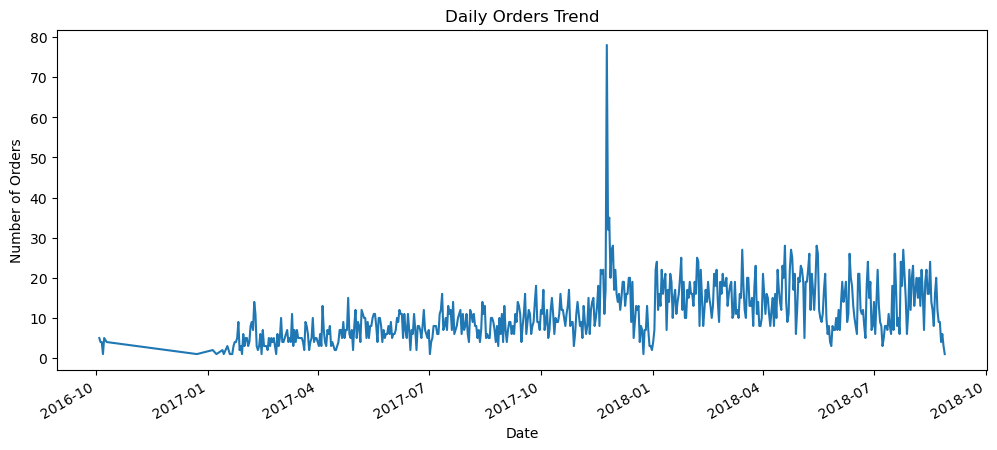

In [9]:
import matplotlib.pyplot as plt

# Orders per day
daily_orders = df.groupby("order_date")["order_id"].count()

# Plot
plt.figure(figsize=(12,5))
daily_orders.plot()
plt.title("Daily Orders Trend")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

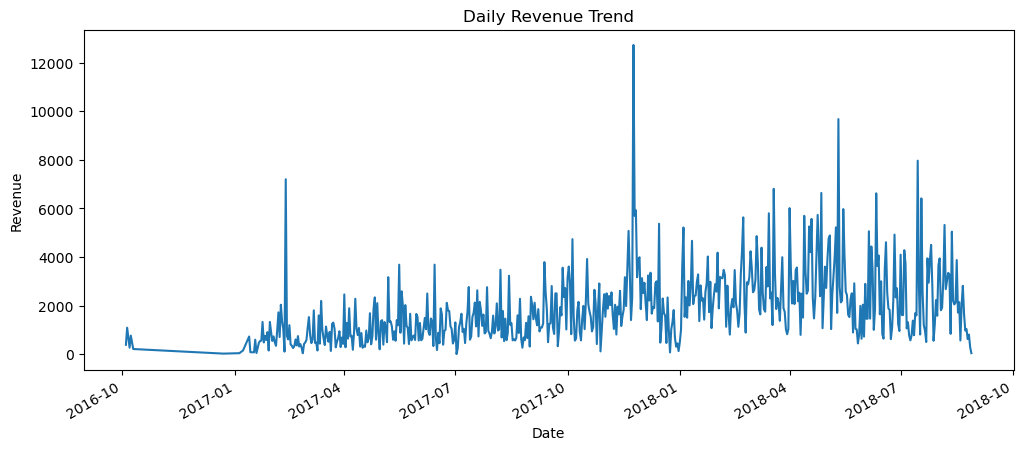

In [10]:
# Revenue per day
daily_revenue = df.groupby("order_date")["payment_value"].sum()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [11]:
# Orders per customer
customer_orders = df.groupby("customer_id")["order_id"].count()

# Count types
one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

print("One-time customers:", one_time)
print("Repeat customers:", repeat)

One-time customers: 6444
Repeat customers: 45


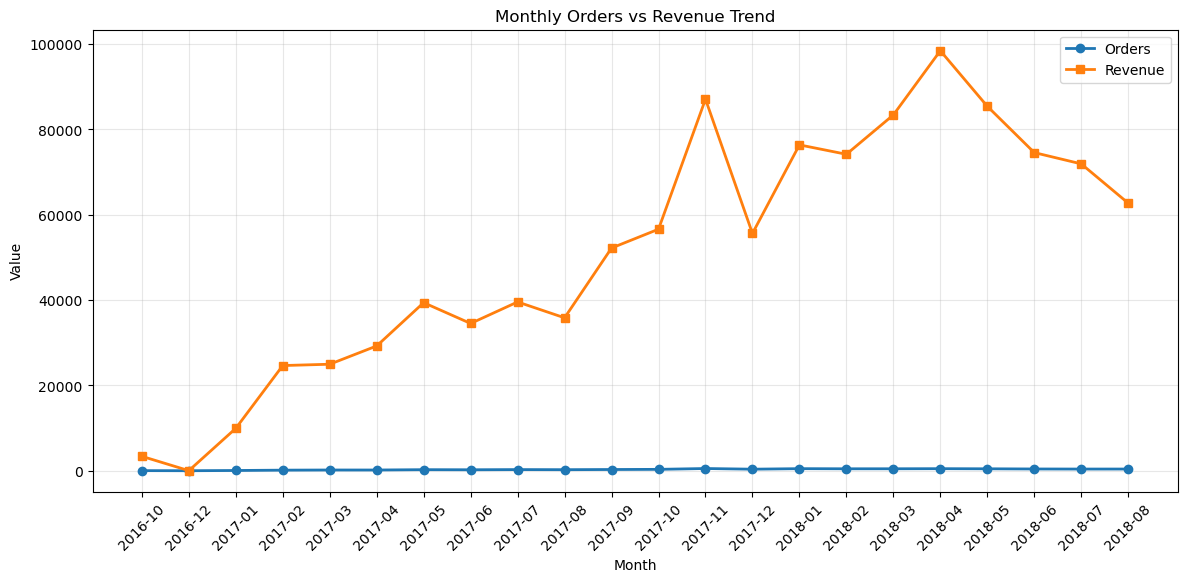

In [12]:
import matplotlib.pyplot as plt

# Create month column
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

# Monthly orders
monthly_orders = df.groupby("order_month")["order_id"].count()

# Monthly revenue
monthly_revenue = df.groupby("order_month")["payment_value"].sum()

# Plot
plt.figure(figsize=(14,6))

# Orders line
plt.plot(monthly_orders.index, monthly_orders.values, 
         marker='o', linewidth=2, label="Orders")

# Revenue line
plt.plot(monthly_revenue.index, monthly_revenue.values, 
         marker='s', linewidth=2, label="Revenue")

plt.xticks(rotation=45)
plt.title("Monthly Orders vs Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [13]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.4 MB/s  0:00:06 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 8.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]


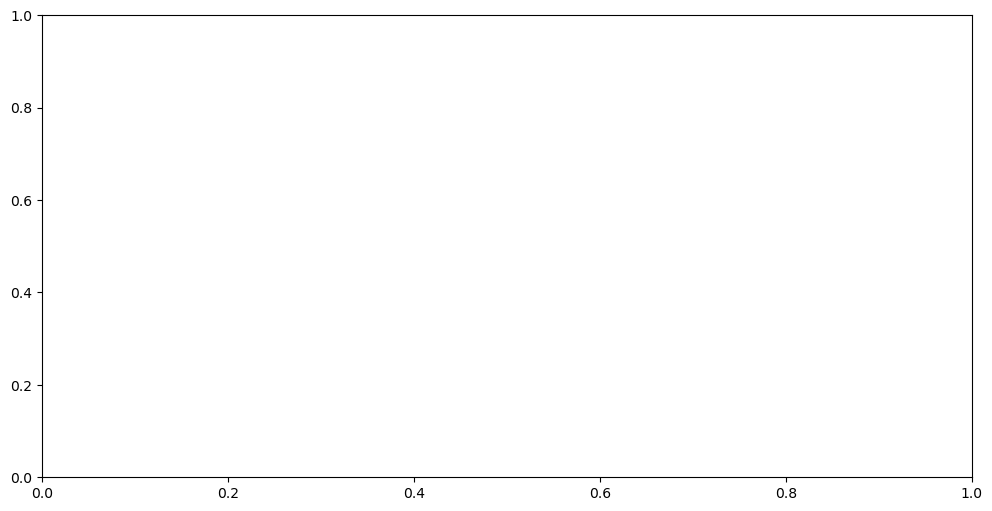

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


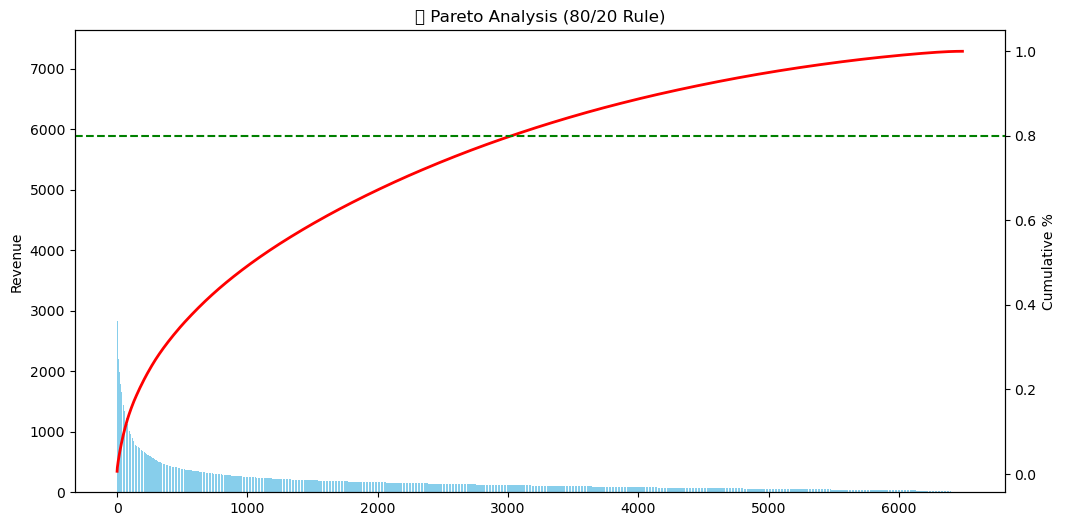

In [15]:
import numpy as np

# Revenue per customer
customer_revenue = df.groupby("customer_id")["payment_value"].sum().sort_values(ascending=False)

# Cumulative %
cum_revenue = customer_revenue.cumsum() / customer_revenue.sum()

# Plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart
ax1.bar(range(len(customer_revenue)), customer_revenue.values, color='skyblue')
ax1.set_ylabel("Revenue")

# Line chart
ax2 = ax1.twinx()
ax2.plot(range(len(customer_revenue)), cum_revenue.values, color='red', linewidth=2)
ax2.set_ylabel("Cumulative %")

ax2.axhline(0.8, color='green', linestyle='--')  # 80% line

plt.title("💎 Pareto Analysis (80/20 Rule)")
plt.show()

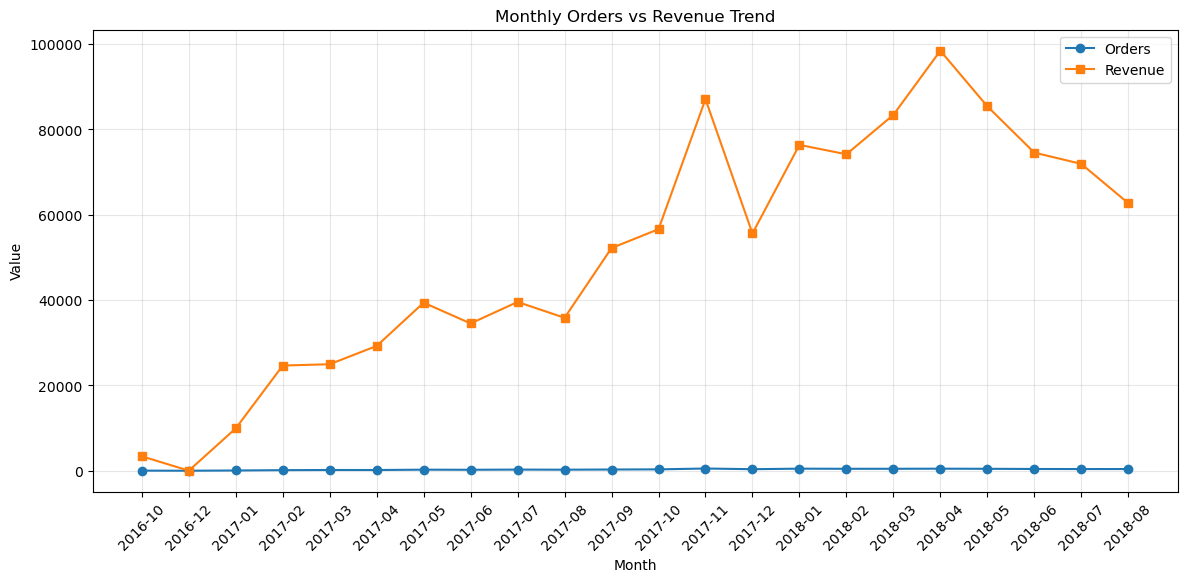

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


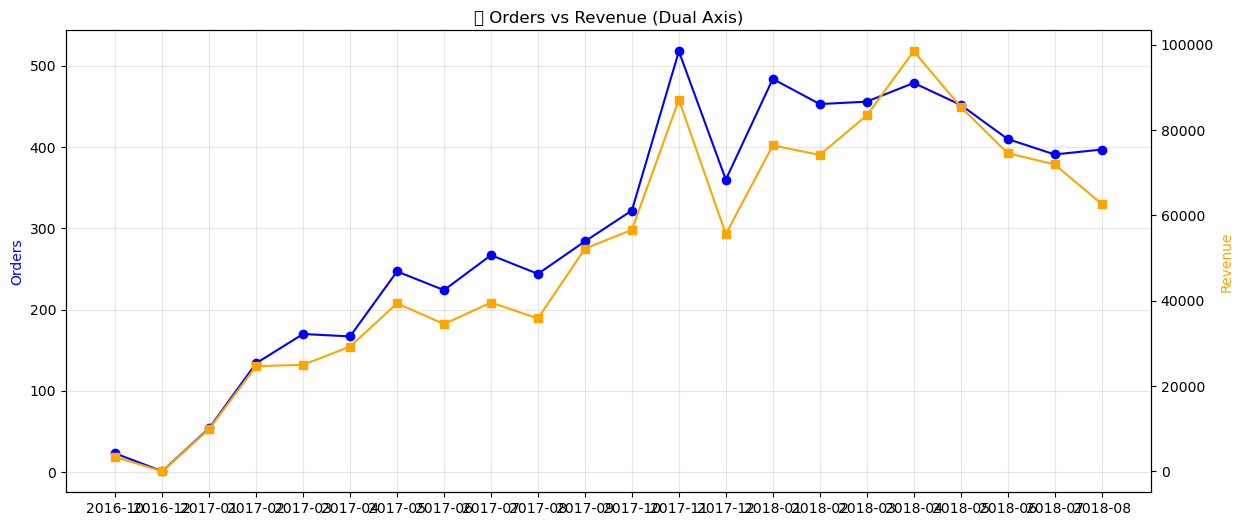

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


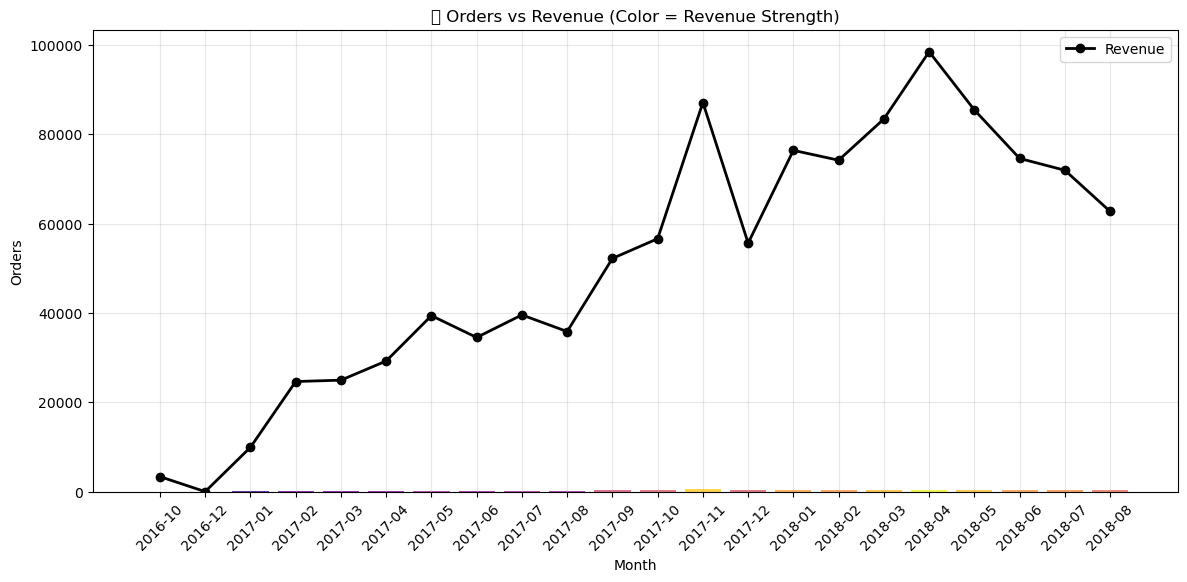

Average Order Value (AOV): 172.6


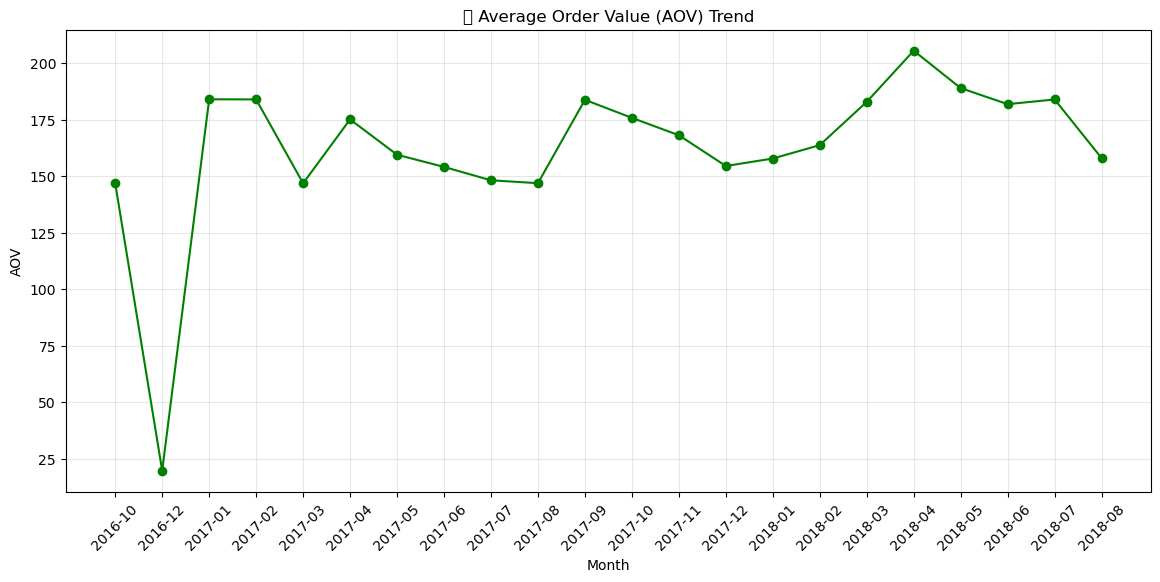


🔍 KEY INSIGHTS:
1. Revenue is growing faster than order volume.
2. Indicates higher spending per customer (AOV increase).
3. Business growth is driven by value, not just volume.
4. Presence of high-value transactions (revenue spikes).


In [16]:
# ================================
# 📦 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 📂 2. LOAD DATA
# ================================
df = pd.read_csv("com.csv")

# ================================
# 🧹 3. DATA CLEANING
# ================================
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df = df.dropna()

# ================================
# 📅 4. FEATURE ENGINEERING
# ================================
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

# ================================
# 📊 5. AGGREGATION
# ================================
monthly_orders = df.groupby("order_month")["order_id"].count()
monthly_revenue = df.groupby("order_month")["payment_value"].sum()

# ================================
# 📈 6. BASIC TREND PLOT
# ================================
plt.figure(figsize=(14,6))

plt.plot(monthly_orders.index, monthly_orders.values,
         marker='o', label="Orders")

plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker='s', label="Revenue")

plt.xticks(rotation=45)
plt.title("Monthly Orders vs Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ================================
# 🔥 7. DUAL AXIS (PROFESSIONAL)
# ================================
fig, ax1 = plt.subplots(figsize=(14,6))

# Orders
ax1.plot(monthly_orders.index, monthly_orders.values,
         color='blue', marker='o', label="Orders")
ax1.set_ylabel("Orders", color='blue')

# Revenue
ax2 = ax1.twinx()
ax2.plot(monthly_revenue.index, monthly_revenue.values,
         color='orange', marker='s', label="Revenue")
ax2.set_ylabel("Revenue", color='orange')

plt.xticks(rotation=45)
plt.title("📊 Orders vs Revenue (Dual Axis)")
ax1.grid(alpha=0.3)

plt.show()

# ================================
# 🎨 8. INSANE VISUAL (COLOR INTENSITY)
# ================================
norm = (monthly_revenue - monthly_revenue.min()) / (monthly_revenue.max() - monthly_revenue.min())
colors = plt.cm.plasma(norm)

plt.figure(figsize=(14,6))

# Bars (orders)
plt.bar(monthly_orders.index, monthly_orders.values,
        color=colors, alpha=0.8)

# Line (revenue)
plt.plot(monthly_revenue.index, monthly_revenue.values,
         color='black', marker='o', linewidth=2, label='Revenue')

plt.xticks(rotation=45)
plt.title("🔥 Orders vs Revenue (Color = Revenue Strength)")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ================================
# 💰 9. AVERAGE ORDER VALUE (AOV)
# ================================
aov = df["payment_value"].sum() / df["order_id"].nunique()
print("Average Order Value (AOV):", round(aov, 2))

# ================================
# 📈 10. AOV TREND OVER TIME
# ================================
monthly_aov = monthly_revenue / monthly_orders

plt.figure(figsize=(14,6))
plt.plot(monthly_aov.index, monthly_aov.values,
         marker='o', color='green')

plt.xticks(rotation=45)
plt.title("📊 Average Order Value (AOV) Trend")
plt.xlabel("Month")
plt.ylabel("AOV")
plt.grid(alpha=0.3)

plt.show()

# ================================
# 🧠 11. FINAL INSIGHTS (PRINT)
# ================================
print("\n🔍 KEY INSIGHTS:")
print("1. Revenue is growing faster than order volume.")
print("2. Indicates higher spending per customer (AOV increase).")
print("3. Business growth is driven by value, not just volume.")
print("4. Presence of high-value transactions (revenue spikes).")

Average CLV: 172.5990229619356
Max CLV: 7274.88
Min CLV: 0.28


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


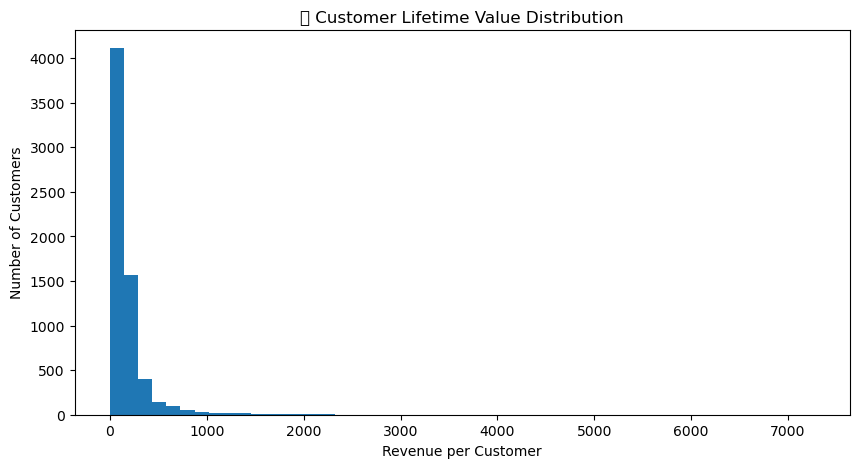

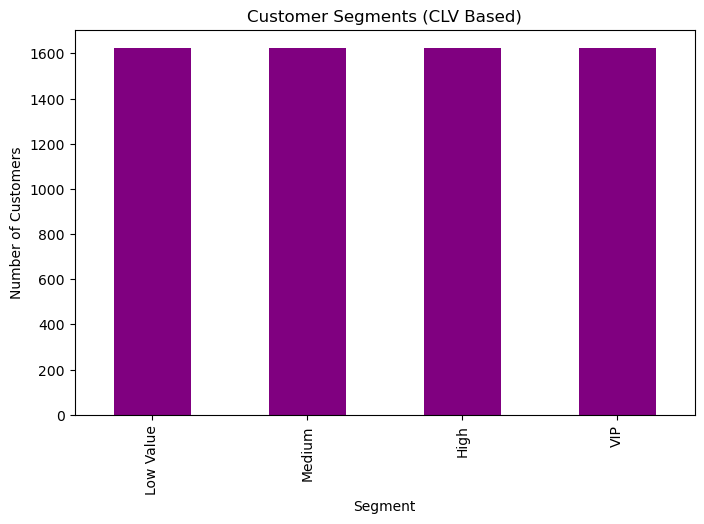

In [17]:
# Total revenue per customer
customer_revenue = df.groupby("customer_id")["payment_value"].sum()

customer_revenue.head()
print("Average CLV:", customer_revenue.mean())
print("Max CLV:", customer_revenue.max())
print("Min CLV:", customer_revenue.min())
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(customer_revenue, bins=50)

plt.title("💎 Customer Lifetime Value Distribution")
plt.xlabel("Revenue per Customer")
plt.ylabel("Number of Customers")

plt.show()
# Segment customers into 4 groups
segments = pd.qcut(customer_revenue, 4, labels=[
    "Low Value", "Medium", "High", "VIP"
])

segments.value_counts()
segments.value_counts().plot(kind="bar", figsize=(8,5), color="purple")

plt.title("Customer Segments (CLV Based)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


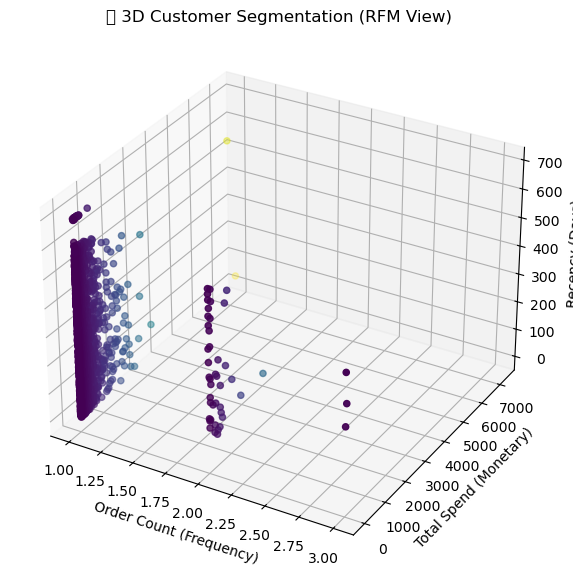

In [19]:
# Create customer-level dataset again
customer_df = df.groupby("customer_id").agg({
    "payment_value": "sum",
    "order_id": "count",
    "order_date": "max"
}).reset_index()

# Rename columns
customer_df.columns = ["customer_id", "total_spent", "order_count", "last_purchase"]

# Recency
latest_date = df["order_date"].max()
customer_df["recency"] = (latest_date - customer_df["last_purchase"]).dt.days

customer_df.head()
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

x = customer_df["order_count"]
y = customer_df["total_spent"]
z = customer_df["recency"]

scatter = ax.scatter(x, y, z, c=y, cmap='viridis', s=20)

ax.set_xlabel("Order Count (Frequency)")
ax.set_ylabel("Total Spend (Monetary)")
ax.set_zlabel("Recency (Days)")

plt.title("🔥 3D Customer Segmentation (RFM View)")

plt.show()

In [20]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 8.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


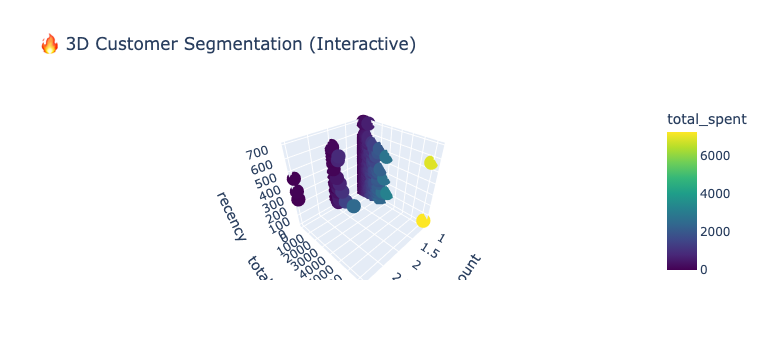

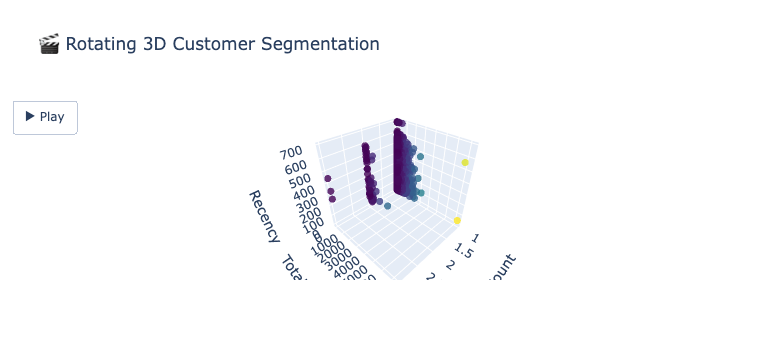

In [21]:
import plotly.express as px

fig = px.scatter_3d(
    customer_df,
    x="order_count",
    y="total_spent",
    z="recency",
    color="total_spent",
    color_continuous_scale="viridis",
    title="🔥 3D Customer Segmentation (Interactive)"
)

fig.show()
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure(
    data=[go.Scatter3d(
        x=customer_df["order_count"],
        y=customer_df["total_spent"],
        z=customer_df["recency"],
        mode='markers',
        marker=dict(
            size=4,
            color=customer_df["total_spent"],
            colorscale='Viridis',
            opacity=0.8
        )
    )]
)

# Create rotating frames
frames = []
angles = np.linspace(0, 360, 60)

for angle in angles:
    camera = dict(
        eye=dict(
            x=2*np.cos(np.radians(angle)),
            y=2*np.sin(np.radians(angle)),
            z=0.5
        )
    )
    frames.append(go.Frame(layout=dict(scene_camera=camera)))

fig.frames = frames

# Add play button
fig.update_layout(
    title="🎬 Rotating 3D Customer Segmentation",
    scene=dict(
        xaxis_title="Order Count",
        yaxis_title="Total Spend",
        zaxis_title="Recency"
    ),
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        buttons=[dict(
            label="▶ Play",
            method="animate",
            args=[None, {"frame": {"duration": 100, "redraw": True},
                         "fromcurrent": True}]
        )]
    )]
)

fig.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.



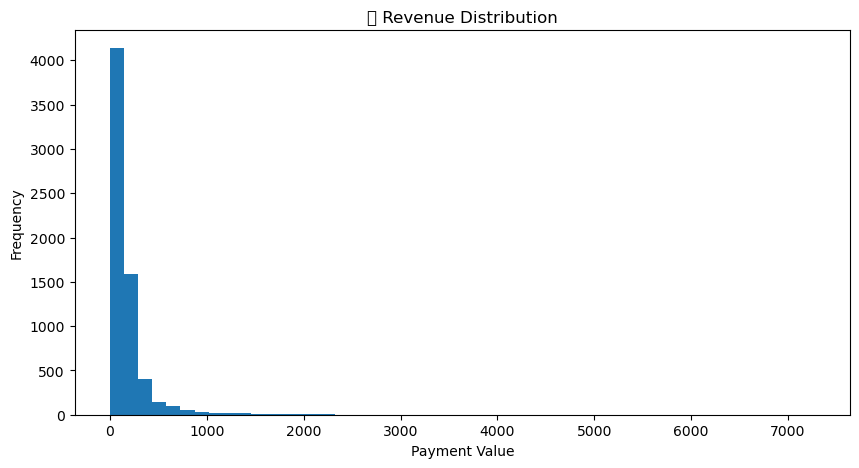

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



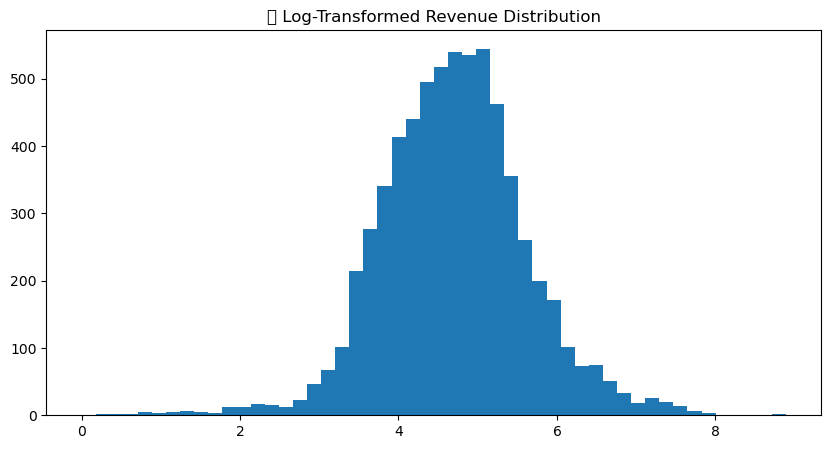

In [22]:
# Revenue stats
df["payment_value"].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["payment_value"], bins=50)

plt.title("💰 Revenue Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")

plt.show()
import numpy as np

log_revenue = np.log1p(df["payment_value"])

plt.figure(figsize=(10,5))
plt.hist(log_revenue, bins=50)

plt.title("📊 Log-Transformed Revenue Distribution")
plt.show()


In [23]:
import numpy as np

# Create random groups
df["group"] = np.random.choice(["A", "B"], size=len(df))

# Check distribution
df["group"].value_counts()

group
A    3289
B    3248
Name: count, dtype: int64

In [24]:
group_means = df.groupby("group")["payment_value"].mean()

print(group_means)

group
A    169.841836
B    172.840289
Name: payment_value, dtype: float64


In [25]:
from scipy.stats import ttest_ind

group_A = df[df["group"] == "A"]["payment_value"]
group_B = df[df["group"] == "B"]["payment_value"]

t_stat, p_value = ttest_ind(group_A, group_B)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.47479886288387896
P-value: 0.6349462097303755


In [26]:
mean_A = df[df["group"] == "A"]["payment_value"].mean()
mean_B = df[df["group"] == "B"]["payment_value"].mean()

diff = mean_B - mean_A

print("Mean A:", mean_A)
print("Mean B:", mean_B)
print("Difference (B - A):", diff)

Mean A: 169.8418364244451
Mean B: 172.840289408867
Difference (B - A): 2.9984529844219026


In [27]:
import numpy as np

group_A = df[df["group"] == "A"]["payment_value"]
group_B = df[df["group"] == "B"]["payment_value"]

# Means
mean_A = group_A.mean()
mean_B = group_B.mean()

# Standard error
se = np.sqrt(group_A.var()/len(group_A) + group_B.var()/len(group_B))

# 95% CI
ci_low = (mean_B - mean_A) - 1.96 * se
ci_high = (mean_B - mean_A) + 1.96 * se

print("Confidence Interval:")
print(ci_low, "to", ci_high)

Confidence Interval:
-9.3673785141813 to 15.364284483025106


In [28]:
import numpy as np

group_A = df[df["group"] == "A"]["payment_value"]
group_B = df[df["group"] == "B"]["payment_value"]

# Means
mean_A = group_A.mean()
mean_B = group_B.mean()

# Standard deviations
std_A = group_A.std()
std_B = group_B.std()

# Sample sizes
n_A = len(group_A)
n_B = len(group_B)

# Pooled standard deviation
pooled_std = np.sqrt(((n_A - 1)*std_A**2 + (n_B - 1)*std_B**2) / (n_A + n_B - 2))

# Cohen's d
cohen_d = (mean_B - mean_A) / pooled_std

print("Cohen's d:", cohen_d)

Cohen's d: 0.011745160763791535


6489 6489 6489


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



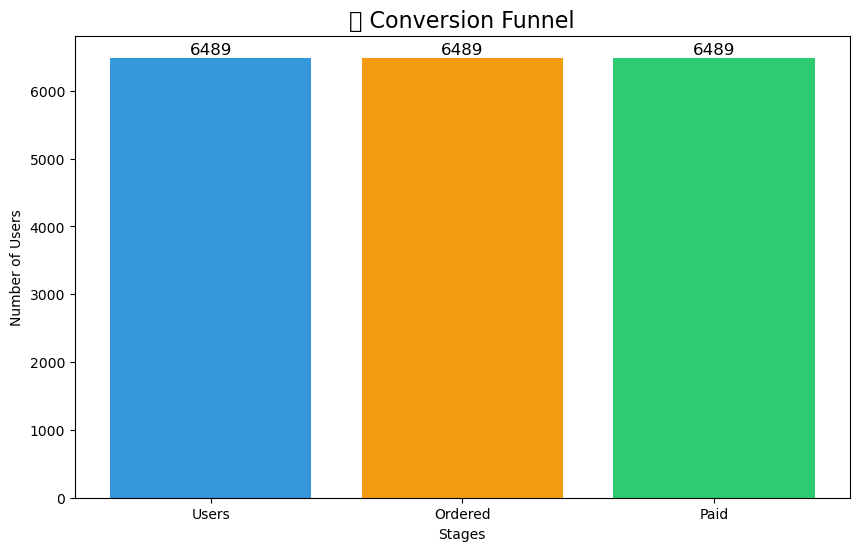

In [30]:
import matplotlib.pyplot as plt
# Recreate funnel values

total_users = df["customer_id"].nunique()
ordered_users = df[df["order_id"].notnull()]["customer_id"].nunique()
paid_users = df[df["payment_value"] > 0]["customer_id"].nunique()

print(total_users, ordered_users, paid_users)
# Funnel values
stages = ["Users", "Ordered", "Paid"]
values = [total_users, ordered_users, paid_users]

# Colors (attractive gradient)
colors = ["#3498db", "#f39c12", "#2ecc71"]

plt.figure(figsize=(10,6))

bars = plt.bar(stages, values, color=colors)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.title("🔥 Conversion Funnel", fontsize=16)
plt.xlabel("Stages")
plt.ylabel("Number of Users")

plt.show()

In [36]:
df.columns

Index(['order_id', 'customer_id', 'customer_city', 'customer_state',
       'order_date', 'order_month', 'product_id', 'product_category_name',
       'price', 'payment_value', 'review_score', 'group'],
      dtype='object')

Users: 6489
Orders: 6489
Revenue: 1119995.06
Revenue per User: 172.60
Revenue per Order: 172.60


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.



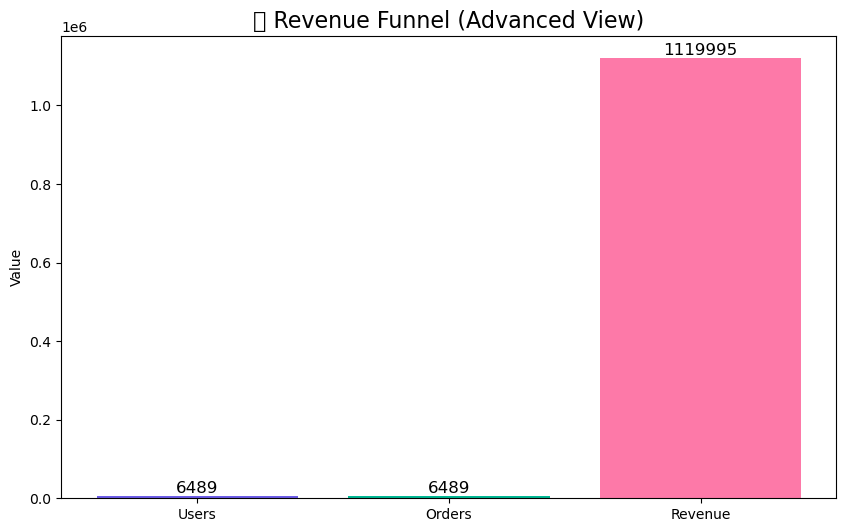

In [37]:
# Revenue funnel stages

total_users = df["customer_id"].nunique()
total_orders = df["order_id"].nunique()
total_revenue = df["payment_value"].sum()

print("Users:", total_users)
print("Orders:", total_orders)
print("Revenue:", total_revenue)
# Derived funnel metrics

revenue_per_user = total_revenue / total_users
revenue_per_order = total_revenue / total_orders

print(f"Revenue per User: {revenue_per_user:.2f}")
print(f"Revenue per Order: {revenue_per_order:.2f}")
import matplotlib.pyplot as plt

stages = ["Users", "Orders", "Revenue"]
values = [total_users, total_orders, total_revenue]

colors = ["#6C5CE7", "#00B894", "#FD79A8"]

plt.figure(figsize=(10,6))

bars = plt.bar(stages, values, color=colors)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.title("💰 Revenue Funnel (Advanced View)", fontsize=16)
plt.ylabel("Value")

plt.show()

In [38]:
# Orders per customer
customer_orders = df.groupby("customer_id")["order_id"].nunique()

# Retained users = customers with >1 order
retained_users = (customer_orders > 1).sum()

# Total users
total_users = customer_orders.count()

# Retention rate
retention_rate = (retained_users / total_users) * 100

print("Total Users:", total_users)
print("Retained Users:", retained_users)
print(f"Retention Rate: {retention_rate:.2f}%")

Total Users: 6489
Retained Users: 0
Retention Rate: 0.00%


Total Users: 6489
Engaged Users: 1884
High Value Users: 1622


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



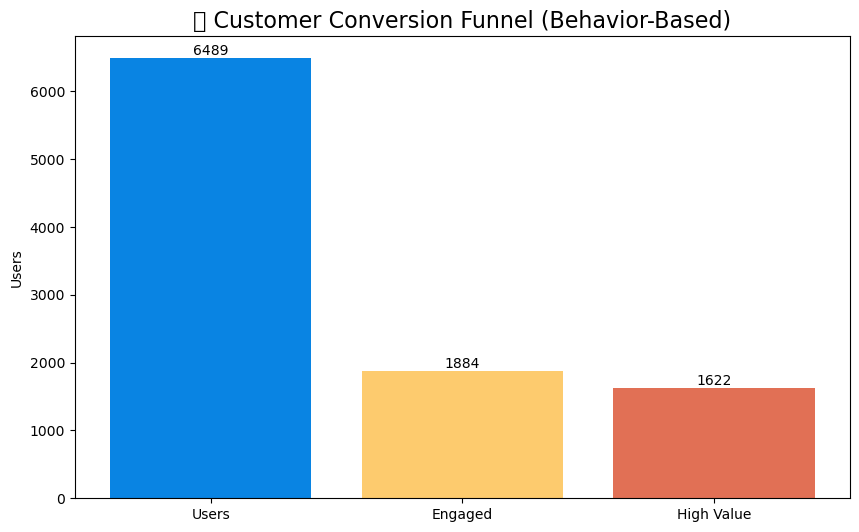

In [39]:
# Step 1: Total users
total_users = df["customer_id"].nunique()

# Step 2: Engaged users (users with above-average spend)
avg_spend = df["payment_value"].mean()

user_spend = df.groupby("customer_id")["payment_value"].sum()

engaged_users = (user_spend > avg_spend).sum()

# Step 3: High-value users (top 25%)
threshold = user_spend.quantile(0.75)
high_value_users = (user_spend > threshold).sum()

print("Total Users:", total_users)
print("Engaged Users:", engaged_users)
print("High Value Users:", high_value_users)
import matplotlib.pyplot as plt

stages = ["Users", "Engaged", "High Value"]
values = [total_users, engaged_users, high_value_users]

colors = ["#0984e3", "#fdcb6e", "#e17055"]

plt.figure(figsize=(10,6))

bars = plt.bar(stages, values, color=colors)

# Labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom')

plt.title("🔥 Customer Conversion Funnel (Behavior-Based)", fontsize=16)
plt.ylabel("Users")

plt.show()

Users → Engaged: 29.03%
Engaged → High Value: 86.09%
Overall Conversion (Users → High Value): 25.00%


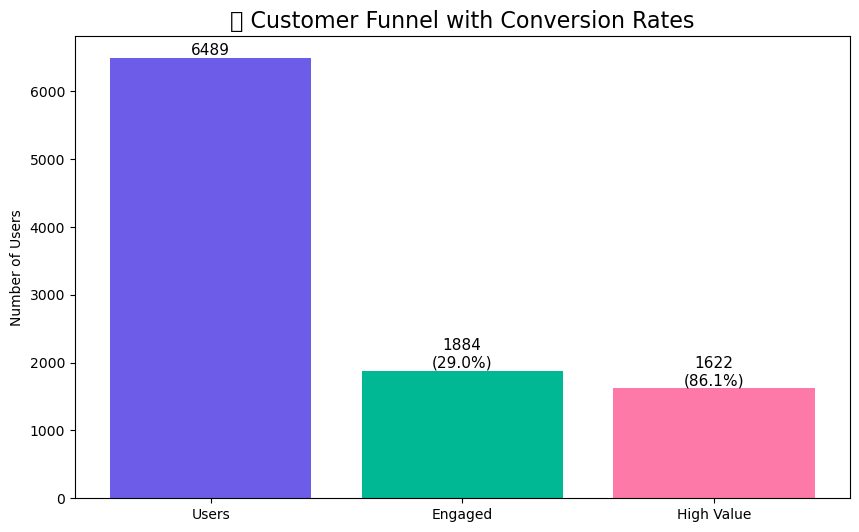

In [40]:
# Stage values (already computed)
users = total_users
engaged = engaged_users
high_value = high_value_users

# Conversion rates
engagement_rate = (engaged / users) * 100
high_value_rate = (high_value / engaged) * 100
overall_conversion = (high_value / users) * 100

print(f"Users → Engaged: {engagement_rate:.2f}%")
print(f"Engaged → High Value: {high_value_rate:.2f}%")
print(f"Overall Conversion (Users → High Value): {overall_conversion:.2f}%")
import matplotlib.pyplot as plt

stages = ["Users", "Engaged", "High Value"]
values = [users, engaged, high_value]

colors = ["#6c5ce7", "#00b894", "#fd79a8"]

plt.figure(figsize=(10,6))
bars = plt.bar(stages, values, color=colors)

# Add labels + conversion %
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    if i == 0:
        label = f"{int(height)}"
    elif i == 1:
        label = f"{int(height)}\n({engagement_rate:.1f}%)"
    else:
        label = f"{int(height)}\n({high_value_rate:.1f}%)"
    
    plt.text(bar.get_x() + bar.get_width()/2, height,
             label, ha='center', va='bottom', fontsize=11)

plt.title("🔥 Customer Funnel with Conversion Rates", fontsize=16)
plt.ylabel("Number of Users")

plt.show()

cohort_index    0
cohort_month     
2016-10       1.0
2016-12       1.0
2017-01       1.0
2017-02       1.0
2017-03       1.0
2017-04       1.0
2017-05       1.0
2017-06       1.0
2017-07       1.0
2017-08       1.0
2017-09       1.0
2017-10       1.0
2017-11       1.0
2017-12       1.0
2018-01       1.0
2018-02       1.0
2018-03       1.0
2018-04       1.0
2018-05       1.0
2018-06       1.0
2018-07       1.0
2018-08       1.0


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.



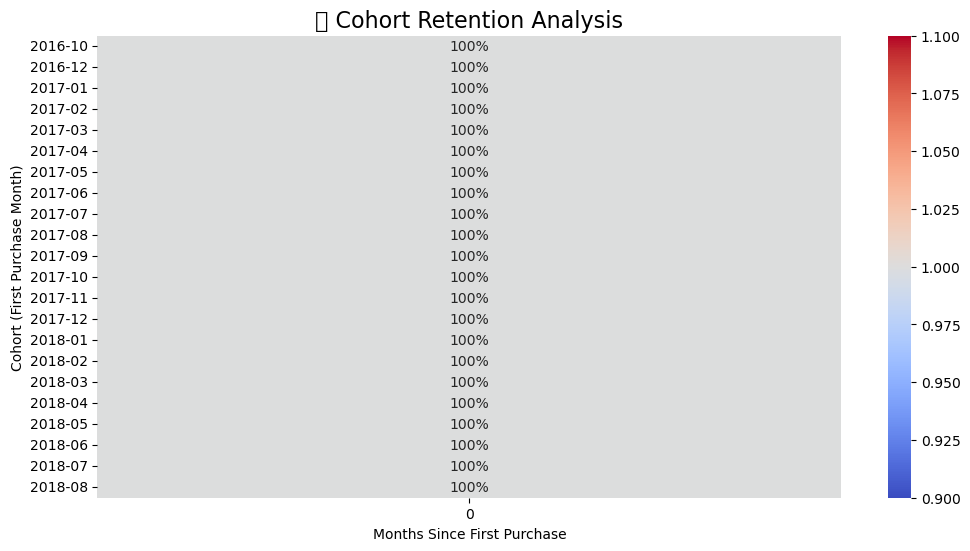

In [41]:
import pandas as pd

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month (YYYY-MM)
df['order_month'] = df['order_date'].dt.to_period('M')

# First purchase month per customer
df['cohort_month'] = df.groupby('customer_id')['order_date'] \
                       .transform('min') \
                       .dt.to_period('M')
# Calculate months difference
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'] \
                .nunique() \
                .reset_index()

cohort_pivot = cohort_data.pivot(index='cohort_month',
                                 columns='cohort_index',
                                 values='customer_id')
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention = retention.round(3)

print(retention)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(retention,
            annot=True,
            fmt=".0%",
            cmap="coolwarm")

plt.title("🔥 Cohort Retention Analysis", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")

plt.show()


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.



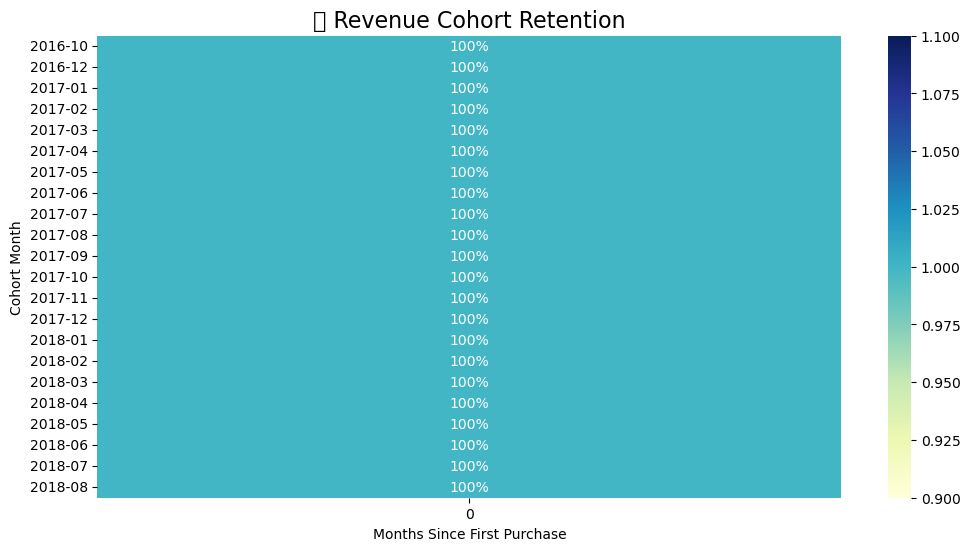

In [43]:
# Revenue Cohort Preparation
df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.to_period('M')

df['cohort_month'] = df.groupby('customer_id')['order_date'] \
                       .transform('min') \
                       .dt.to_period('M')
# Cohort index
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Revenue cohort
revenue_cohort = df.groupby(['cohort_month', 'cohort_index'])['payment_value'] \
                   .sum() \
                   .reset_index()

# Pivot
revenue_pivot = revenue_cohort.pivot(index='cohort_month',
                                     columns='cohort_index',
                                     values='payment_value')

# Normalize
cohort_revenue_base = revenue_pivot.iloc[:, 0]
revenue_retention = revenue_pivot.divide(cohort_revenue_base, axis=0)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(revenue_retention,
            annot=True,
            fmt=".0%",
            cmap="YlGnBu")

plt.title("💰 Revenue Cohort Retention", fontsize=16)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

order_month
2016-10     3376.68
2016-12       19.62
2017-01     9936.88
2017-02    24650.75
2017-03    24961.22
2017-04    29244.59
2017-05    39389.90
2017-06    34515.57
2017-07    39558.69
2017-08    35840.89
2017-09    52193.95
2017-10    56607.18
2017-11    87080.34
2017-12    55621.25
2018-01    76372.43
2018-02    74169.65
2018-03    83396.13
2018-04    98441.01
2018-05    85416.35
2018-06    74565.35
2018-07    71920.13
2018-08    62716.50
Freq: M, Name: payment_value, dtype: float64
order_month
2016-10     23
2016-12      1
2017-01     52
2017-02    132
2017-03    167
2017-04    165
2017-05    245
2017-06    221
2017-07    267
2017-08    242
2017-09    281
2017-10    321
2017-11    514
2017-12    356
2018-01    481
2018-02    452
2018-03    454
2018-04    472
2018-05    449
2018-06    406
2018-07    391
2018-08    397
Freq: M, Name: customer_id, dtype: int64
order_month
2016-10    146.812174
2016-12     19.620000
2017-01    191.093846
2017-02    186.748106
2017-03    149.46838

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.



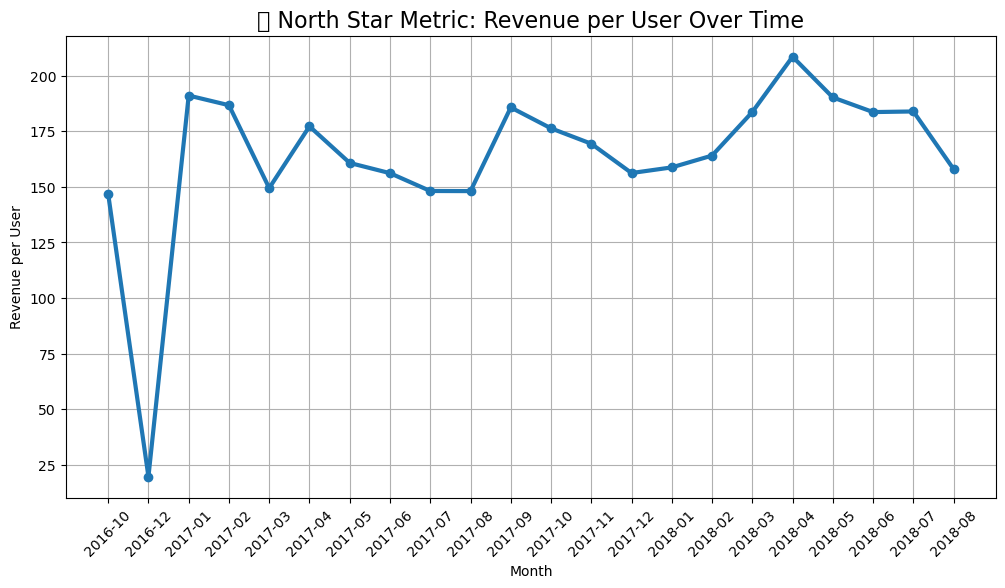

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



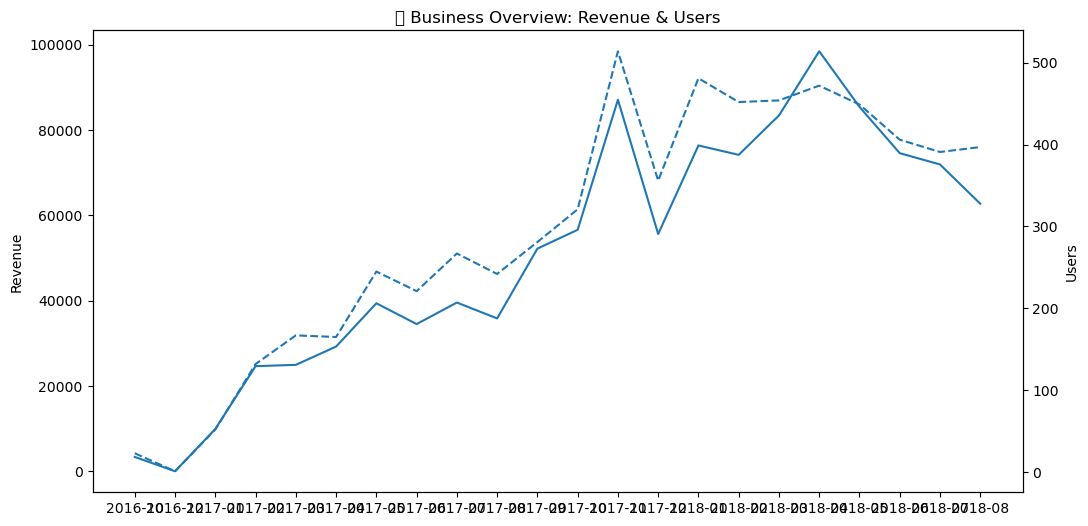

In [46]:
import pandas as pd

# Ensure datetime format
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

print(monthly_revenue)
monthly_users = df.groupby('order_month')['customer_id'].nunique()

print(monthly_users)
nsm = monthly_revenue / monthly_users

nsm = nsm.rename("Revenue_per_User")

print(nsm)
nsm_df = pd.concat([monthly_revenue, monthly_users, nsm], axis=1)
nsm_df.columns = ['Revenue', 'Active Users', 'Revenue per User']

print(nsm_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(nsm_df.index.astype(str), nsm_df['Revenue per User'], 
         marker='o', linewidth=3)

plt.title("⭐ North Star Metric: Revenue per User Over Time", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue per User")
plt.grid(True)

plt.xticks(rotation=45)
plt.show()
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue
ax1.plot(nsm_df.index.astype(str), nsm_df['Revenue'], label='Revenue')
ax1.set_ylabel("Revenue")

# Second axis for users
ax2 = ax1.twinx()
ax2.plot(nsm_df.index.astype(str), nsm_df['Active Users'], linestyle='--', label='Users')
ax2.set_ylabel("Users")

plt.title("📊 Business Overview: Revenue & Users")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Monthly revenue growth %
growth_rate = monthly_revenue.pct_change() * 100

growth_rate = growth_rate.rename("Revenue Growth %")

print(growth_rate)
nsm_df['Growth Rate (%)'] = growth_rate

print(nsm_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(nsm_df.index.astype(str), nsm_df['Growth Rate (%)'], 
         marker='o', color='#e17055', linewidth=2)

plt.axhline(0, color='black', linestyle='--')

plt.title("🚀 Revenue Growth Rate Over Time", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Growth %")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()
# Top 25% threshold
threshold = df['payment_value'].quantile(0.75)

# High value users
high_value_users = df[df['payment_value'] > threshold]['customer_id'].nunique()

# Total users
total_users = df['customer_id'].nunique()

ratio = (high_value_users / total_users) * 100

print(f"High Value Customer Ratio: {ratio:.2f}%")